# Notebook for conducting the main sizing of the 5 design options for trade-off

In [10]:
import sys
import os
import matplotlib.pyplot as plt
import numpy.typing as nt
import aerosandbox.numpy as np

# Add the 'src' directory to the python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))

from src.Sizing_Loop.SizingForTradeoff import SizingForTradeoff, DesignOptionState, Assumptions

## Generating the initial values and decisions for design options

In [2]:
sizing_for_tradeoff = SizingForTradeoff()

for configuration in sizing_for_tradeoff.configurations:
    print()
    print(configuration.name)
    print("high wing" if np.isclose(configuration.wing_interference_factor, 1.) else "low wing")
    print("movable wing port" if configuration.main_wing_x_movable else "fixed wing port")
    print("canard capability" if configuration.canard_capability else "no canard port")
    print("sideways extending landing gear" if configuration.landing_gear_sideways_extendable else "downwards extending landing gear")


HUG-CFG-301
low wing
movable wing port
canard capability
sideways extending landing gear

HUG-CFG-302
high wing
fixed wing port
no canard port
downwards extending landing gear

HUG-CFG-303
high wing
fixed wing port
canard capability
sideways extending landing gear

HUG-CFG-304
high wing
movable wing port
canard capability
downwards extending landing gear

HUG-CFG-305
high wing
movable wing port
canard capability
sideways extending landing gear


## Specifying the settings of the analysis

In [3]:
sizing_for_tradeoff.accumulate_steps()

In [4]:
def tracked_varaibles(state:DesignOptionState) -> nt.NDArray[np.float64]:
    return np.array([
        state.iterable.aircraft_parameters.total_mass
    ])

In [5]:
n_iterations = 6

## Analyses per uncertain parameter

### 1. Gear Pod width

In [6]:
pod_widths_to_wheel_diameters = np.linspace(1.5, 3., 2)

def pod_width_to_wheel_setter(assumptions:Assumptions, current_value:float) -> Assumptions:
    assumptions.lg_bay_wheel_diameter_ratio = current_value
    return assumptions

In [7]:
pod_width_sweep = sizing_for_tradeoff.sweep_wrt_parameter(pod_width_to_wheel_setter, pod_widths_to_wheel_diameters, n_iterations, tracked_varaibles)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.49795418253271856
            Iterations: 4
            Function evaluations: 17
            Gradient evaluations: 4
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.4869322781314943
            Iterations: 4
            Function evaluations: 17
            Gradient evaluations: 4
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.4809575862911635
            Iterations: 4
            Function evaluations: 17
            Gradient evaluations: 4
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.4784179391406263
            Iterations: 4
            Function evaluations: 17
            Gradient evaluations: 4
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.47864737190272316
            Iterations: 4
            Function evaluation

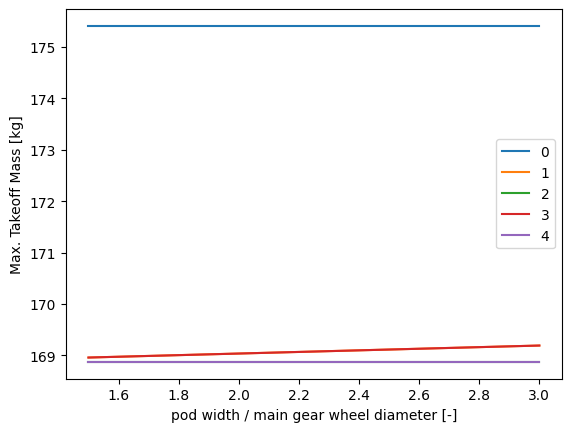

In [ ]:
n_options = len(sizing_for_tradeoff.configurations)
weight_values_wrt_pod = np.reshape(np.array(pod_width_sweep), (len(pod_widths_to_wheel_diameters), n_options))

for i, configuration in enumerate(sizing_for_tradeoff.configurations):
    plt.plot(pod_widths_to_wheel_diameters, weight_values_wrt_pod[:, i], label=configuration.name)

plt.ylabel("Max. Takeoff Mass [kg]")
plt.xlabel("pod width / main gear wheel diameter [-]")
plt.legend()